## 0. Cài đặt

In [1]:
# torch_geometric không có sẵn trên Kaggle
!pip install -q torch_geometric

import torch, torch_geometric
print("torch", torch.__version__, "| PyG", torch_geometric.__version__,
      "| GPU", torch.cuda.device_count())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.0 MB/s eta 0:00:00a 0:00:01
torch 2.10.0+cu128 | PyG 2.8.0.post1 | GPU 2


## 1. Ghi code ra /kaggle/working

Sửa code thì sửa ngay trong cell rồi chạy lại đúng cell đó.

In [2]:
%%writefile /kaggle/working/paths.py
import glob
import os

_ON_KAGGLE = os.path.isdir("/kaggle/working")


def _detect_raw_dir() -> str:
    env = os.environ.get("AML_RAW_DIR")
    if env:
        return env
    if _ON_KAGGLE:
        hits = sorted(glob.glob("/kaggle/input/**/HI-Small_Trans.csv", recursive=True))
        if not hits:
            raise FileNotFoundError(
                "Không thấy HI-Small_Trans.csv trong /kaggle/input.\n"
            )
        return os.path.dirname(hits[0])
    return "dataset_high"


RAW_DIR = _detect_raw_dir()
OUT_DIR = os.environ.get("AML_OUT_DIR") or (
    "/kaggle/working/dataset_high" if _ON_KAGGLE else "dataset_high"
)
WORK_DIR = os.path.dirname(os.path.abspath(OUT_DIR))

# --- input gốc (read-only trên Kaggle) ---
TRANS_CSV = os.path.join(RAW_DIR, "HI-Small_Trans.csv")

# --- file trung gian (ghi được) ---
SPLIT_CSV = os.path.join(OUT_DIR, "HI-Small_Trans_split_index.csv")
TX_FEAT = os.path.join(OUT_DIR, "transaction_features.parquet")
NODE_FEAT = os.path.join(OUT_DIR, "node_edge_features.parquet")
EDGE_ATTR = os.path.join(OUT_DIR, "edge_attr_{}.parquet")
TXN_MATRIX = os.path.join(OUT_DIR, "txn_matrix_{}.parquet")
GRAPHS_PT = os.path.join(OUT_DIR, "graphs.pt")
TXN_NODES = os.path.join(OUT_DIR, "txn_nodes.npy")
# --- output kết quả ---
RESULTS_CSV = os.path.join(WORK_DIR, "results_v3.csv")
SCORES_DIR = os.path.join(WORK_DIR, "scores")

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SCORES_DIR, exist_ok=True)


def describe() -> str:
    return (f"môi trường : {'Kaggle' if _ON_KAGGLE else 'local'}\n"
            f"RAW_DIR    : {RAW_DIR}\n"
            f"OUT_DIR    : {OUT_DIR}\n"
            f"WORK_DIR   : {WORK_DIR}")


if __name__ == "__main__":
    print(describe())
    print(f"\nTRANS_CSV tồn tại: {os.path.exists(TRANS_CSV)}")

Writing /kaggle/working/paths.py


In [3]:
%%writefile /kaggle/working/temporal_split_index.py
import pandas as pd

from paths import TRANS_CSV, SPLIT_CSV


def main():
    dtype = {"From Bank": str, "To Bank": str, "Account": str, "Account.1": str}
    df_trans = pd.read_csv(TRANS_CSV, dtype=dtype)
    order = df_trans["Timestamp"].sort_values(kind="mergesort").index
    df_trans = df_trans.iloc[order].reset_index(drop=True)

    n = len(df_trans)
    t1 = int(n * 0.6)
    t2 = int(n * 0.8)
    ts1 = df_trans["Timestamp"].iloc[t1]
    ts2 = df_trans["Timestamp"].iloc[t2]

    df_trans["split"] = "test"
    df_trans.loc[df_trans["Timestamp"] < ts2, "split"] = "val"
    df_trans.loc[df_trans["Timestamp"] < ts1, "split"] = "train"
    assert df_trans[df_trans.split == "train"]["Timestamp"].max() < df_trans[df_trans.split == "val"]["Timestamp"].min()
    assert df_trans[df_trans.split == "val"]["Timestamp"].max() < df_trans[df_trans.split == "test"]["Timestamp"].min()

    df_trans.to_csv(SPLIT_CSV, index=False)
    print(f"Đã lưu: {SPLIT_CSV}")
    print(df_trans["split"].value_counts())


if __name__ == "__main__":
    main()

Writing /kaggle/working/temporal_split_index.py


In [4]:
%%writefile /kaggle/working/feature_transaction.py
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from paths import SPLIT_CSV, TX_FEAT

SRC = SPLIT_CSV
OUT = TX_FEAT

SCALE_COLS = ["amt_paid_log"]


def load_data():
    dt = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str, "split": str}
    df = pd.read_csv(SRC, dtype=dt, engine="pyarrow")
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
    df["src"] = df["From Bank"] + " | " + df["Account"]
    df["dest"] = df["To Bank"] + " | " + df["Account.1"]
    return df


def build_transaction_features(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    out["amt_paid_log"] = np.log1p(df["Amount Paid"])
    out["is_cross_bank"] = (df["From Bank"] != df["To Bank"]).astype("int8")
    out["is_cross_currency"] = (df["Receiving Currency"] != df["Payment Currency"]).astype("int8")
    out["is_self_loop"] = (df["src"] == df["dest"]).astype("int8")

    # --- Thời gian ---
    hour = df["Timestamp"].dt.hour.astype("int16")
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    day_of_week = df["Timestamp"].dt.dayofweek.astype("int16")
    out["dow_sin"] = np.sin(2 * np.pi * day_of_week / 7)
    out["dow_cos"] = np.cos(2 * np.pi * day_of_week / 7)

    # --- One-hot (Tối ưu RAM bằng cách ép dtype ngay từ đầu) ---
    pf = pd.get_dummies(df["Payment Format"], prefix="pf", dtype="int8")
    ccy = pd.get_dummies(df["Payment Currency"], prefix="ccy", dtype="int8")
    out = pd.concat([out, pf, ccy], axis=1)

    # --- Khóa join và nhãn (Để kiểu string/object để ghi Parquet không lỗi) ---
    out["src"] = df["src"]
    out["dest"] = df["dest"]
    out["Is Laundering"] = df["Is Laundering"].astype("int8")
    out["split"] = df["split"]
    return out


def scale_features(feat: pd.DataFrame, scale_cols=SCALE_COLS):
    tr = feat["split"] == "train"
    scaler = StandardScaler().fit(feat.loc[tr, scale_cols].values)

    out = feat.copy()
    out[scale_cols] = scaler.transform(feat[scale_cols].values)
    return out, scaler


def main():
    print("--- 1. Loading data ---")
    df = load_data()

    print("--- 2. Building features ---")
    feat = build_transaction_features(df)

    print("--- 3. Scaling features (Train-only fit) ---")
    feat, scaler = scale_features(feat)

    os.makedirs(os.path.dirname(OUT), exist_ok=True)

    print("--- 4. Saving features ---")
    try:
        path = OUT
        feat.to_parquet(path, index=False)
        print(f"[Success] Đã lưu dạng Parquet: {path}")
    except Exception as e:
        path = OUT.replace(".parquet", ".csv")
        feat.to_csv(path, index=False)
        print(f"[Warn] Không lưu được Parquet ({e}). Đã fallback lưu CSV: {path}")


    n_feat = feat.shape[1] - 4  # trừ src, dest, Is Laundering, split
    print(f"\nThống kê: rows={len(feat):,} | n_features={n_feat}")

    g = feat.groupby("split", observed=True)["Is Laundering"]
    rep = pd.DataFrame({"n": g.size(), "n_pos": g.sum(), "pos_%": (g.mean() * 100).round(3)})
    print(rep)

    
    f = pd.read_parquet(OUT, columns=["split", "amt_paid_log"])
    print("mean(amt_paid_log) trên train:", f[f.split == "train"]["amt_paid_log"].mean())


if __name__ == "__main__":
    main()

Writing /kaggle/working/feature_transaction.py


In [5]:
%%writefile /kaggle/working/feature_node.py
import gc
import os

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

from paths import SPLIT_CSV, NODE_FEAT

src = SPLIT_CSV
out = NODE_FEAT


def load_data():
    dt = {"From Bank": str, "Account": str, "To Bank": str, "Account.1": str, "split": str}
    df = pd.read_csv(src, dtype=dt, engine="pyarrow")
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
    df["src"] = df["From Bank"] + " | " + df["Account"]
    df["dest"] = df["To Bank"] + " | " + df["Account.1"]
    df["ori_idx"] = np.arange(len(df))
    df = df.sort_values(["Timestamp", "ori_idx"], kind="mergesort").reset_index(drop=True)
    df["time"] = df["Timestamp"].astype("int64")
    df["is_cross_bank"] = df["From Bank"] != df["To Bank"]
    df["is_cross_curcy"] = df["Payment Currency"] != df["Receiving Currency"]
    return df


def asof_block(df, group_cols, amt_col, partner_col, bank_col, curcy_col, pf_encoding, prefix, log_col_out):
    # mean/sum/count
    out = pd.DataFrame(index=df.index)
    keys = [df[c] for c in group_cols]
    g = df.groupby(group_cols, sort=False)
    x = df[amt_col]
    cnt = g.cumcount()
    out[f"{prefix}cnt"] = cnt
    sum_prior = g[amt_col].cumsum() - x
    out[f"{prefix}sum"] = sum_prior
    mean_prior = (sum_prior / cnt).fillna(0)
    out[f"{prefix}mean"] = mean_prior
    # phương sai
    x2 = x ** 2
    sumsq_prior = x2.groupby(keys, sort=False).cumsum() - x2
    meansq_prior = (sumsq_prior / cnt).fillna(0)
    var_prior = meansq_prior - mean_prior ** 2
    std_prior = np.sqrt(np.maximum(var_prior, 0.0))
    out[f"{prefix}std"] = std_prior
    # min/max
    out[f"{prefix}max"] = g[amt_col].cummax().groupby(keys, sort=False).shift(1).fillna(0)
    out[f"{prefix}min"] = g[amt_col].cummin().groupby(keys, sort=False).shift(1).fillna(0)

    def nunique_prior(sub_col):
        flag = (~df.duplicated(subset=group_cols + [sub_col])).astype("float32")
        count = flag.groupby(keys, sort=False).cumsum()
        return count - flag

    if partner_col is not None:
        out[f"{prefix}cnt_partner"] = nunique_prior(partner_col)
    if bank_col is not None:
        out[f"{prefix}cnt_bank"] = nunique_prior(bank_col)
    if curcy_col is not None:
        out[f"{prefix}cnt_curcy"] = nunique_prior(curcy_col)
    for fname, fcol in [("cross_bank", "is_cross_bank"), ("cross_curcy", "is_cross_curcy")]:
        prior_f = df[fcol].groupby(keys, sort=False).cumsum() - df[fcol]
        out[f"{prefix}ratio_{fname}"] = (prior_f / cnt).fillna(0).astype("float32")
    for col in pf_encoding.columns:
        prior_d = pf_encoding[col].groupby(keys, sort=False).cumsum() - pf_encoding[col]
        out[f"{prefix}ratio_{col}"] = (prior_d / cnt).fillna(0).astype("float32")
    first_seen = df["time"].groupby(keys, sort=False).cummin()
    active_time = ((df["time"] - first_seen) / 1e9).fillna(0)
    out[f"{prefix}active_time"] = active_time
    out[f"{prefix}tx_per_day"] = (cnt / (active_time / 86400).clip(lower=1.0)).fillna(0)
    out[f"{prefix}first_seen"] = (cnt == 0).astype("int8")
    log_col_out += [f"{prefix}cnt", f"{prefix}sum", f"{prefix}mean", f"{prefix}std",
                    f"{prefix}max", f"{prefix}min", f"{prefix}tx_per_day", f"{prefix}active_time"]
    for c in (partner_col, curcy_col, bank_col):
        if c is not None:
            suffix = {partner_col: "partner", bank_col: "bank", curcy_col: "curcy"}[c]
            log_col_out.append(f"{prefix}cnt_{suffix}")
    return out


def build_entity_features(df):
    pf_encoding = pd.get_dummies(df["Payment Format"], dtype="int8")
    log_cols = []
    src_block = asof_block(df, ["src"], "Amount Paid", partner_col="dest", bank_col="To Bank",
                           curcy_col="Payment Currency", pf_encoding=pf_encoding,
                           prefix="src_", log_col_out=log_cols)
    dest_block = asof_block(df, ["dest"], "Amount Received", partner_col="src", bank_col="From Bank",
                            curcy_col="Receiving Currency", pf_encoding=pf_encoding,
                            prefix="dest_", log_col_out=log_cols)
    pair_block = asof_block(df, ["src", "dest"], "Amount Paid", partner_col=None, bank_col=None,
                            curcy_col=None, pf_encoding=pf_encoding,
                            prefix="pair_", log_col_out=log_cols)
    asof = pd.concat([src_block, dest_block, pair_block], axis=1)
    # giải phóng sớm: 3 block này chiếm ~2.5GB, không cần giữ sau khi concat
    del src_block, dest_block, pair_block, pf_encoding
    gc.collect()
    asof["split"] = df["split"].values
    asof["ori_idx"] = df["ori_idx"].values
    return asof, log_cols


def verify_asof(df, asof):
    verify = True
    first_row = ~df.duplicated(subset=["src"], keep="first")
    check_first = (asof.loc[first_row, "src_cnt"] == 0).all() and (asof.loc[first_row, "src_first_seen"] == 1).all() \
        and (asof.loc[first_row, "src_sum"] == 0).all()
    print(f"kiểm tra rò rỉ dữ liệu: {check_first} {'PASS' if check_first else 'lỗi check first'}")
    verify &= check_first
    last_row = ~df.duplicated(subset=["src"], keep="last")
    whole_window_count = df.groupby("src")["src"].transform("size")
    check_last = (asof.loc[last_row, "src_cnt"] == whole_window_count.loc[last_row] - 1).all()
    print(f"kiểm tra toàn vẹn: {'PASS' if check_last else 'lỗi check last'}")
    verify &= check_last
    test_rows = df.index[df["split"] == "test"]
    idx = test_rows[len(test_rows) // 2]
    row = df.loc[idx]
    prior_mask = (df["src"] == row["src"]) & ((df["time"] < row["time"]) |
                                              ((df["time"] == row["time"]) & (df["ori_idx"] < row["ori_idx"])))
    manual_cnt = int(prior_mask.sum())
    manual_sum = df.loc[prior_mask, "Amount Paid"].sum()
    got_cnt = asof.loc[idx, "src_cnt"]
    got_sum = asof.loc[idx, "src_sum"]
    spot_check = (manual_cnt == got_cnt) and np.isclose(manual_sum, got_sum)
    print(f"kiểm tra ngẫu nhiên: index={idx}: count ={manual_cnt} vs count.1={got_cnt},"
          f"sum={manual_sum:.2f} vs sum.1={got_sum:.2f}")
    verify &= spot_check
    del first_row, last_row, whole_window_count, prior_mask
    gc.collect()
    if not verify:
        raise AssertionError("check fail sau khi kiểm tra logic")
    print("PASS ALL")


def scale_feature(asof, log_cols):
    out = asof.copy()
    out[log_cols] = np.log1p(out[log_cols].clip(lower=0))
    is_train = out["split"] == "train"
    scaler = StandardScaler().fit(out.loc[is_train, log_cols].values)
    out[log_cols] = scaler.transform(out[log_cols].values)
    return out, scaler


def main():
    df = load_data()
    asof, log_cols = build_entity_features(df)
    verify_asof(df, asof)
    asof, scaler = scale_feature(asof, log_cols)
    gc.collect()
    asof = asof.sort_values("ori_idx").drop(columns="ori_idx")
    os.makedirs(os.path.dirname(out), exist_ok=True)
    asof.to_parquet(out, index=False)
    print(f"Success Đã lưu: {out} shape={asof.shape}")


if __name__ == "__main__":
    main()

Writing /kaggle/working/feature_node.py


In [6]:
%%writefile /kaggle/working/feature_edge.py
import gc
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from feature_node import load_data
from paths import EDGE_ATTR

DELTA_H = 6                                  # độ dài cửa sổ trượt
NS = 1_000_000_000

# Cột sinh ra trong cửa sổ, theo thứ tự ghi ra file
WIN_COLS = [
    "w_deg_out_u", "w_deg_in_u", "w_deg_out_v", "w_deg_in_v",
    "w_fan_out_u", "w_fan_in_u", "w_fan_out_v", "w_fan_in_v",
    "w_amt_out_u", "w_amt_in_v",
    "w_pair_cnt", "w_recip_cnt", "w_scatter", "w_gather",
    "w_ratio_cross_bank_u", "w_ratio_cross_ccy_u",
]
STATIC_COLS = ["is_cross_bank", "is_self_loop"]
FEAT_COLS = WIN_COLS + STATIC_COLS
LOG_COLS = WIN_COLS[:14]

GRAPH_SPLITS = {                             
    "train": ["train"],
    "val":   ["train", "val"],
    "test":  ["train", "val", "test"],
}


def sliding_window(t, u, v, amt, cb, cc, n_node, delta_ns, log_every=500_000):
    """Một lượt quét theo thời gian, con trỏ trái đơn điệu nên tổng chi phí O(n).

    Cửa sổ của dòng i là [t_i - delta, t_i], TÍNH CẢ dòng i (đúng GFP: pattern
    phải chứa chính giao dịch đang xét). Không dòng nào đứng sau i lọt vào.
    """
    n = len(t)
    lo_of = np.searchsorted(t, t - delta_ns, side="left")   # biên trái, không giảm

    # đếm theo node: dùng list Python, nhanh hơn hẳn numpy khi truy cập vô hướng
    deg_out = [0] * n_node
    deg_in = [0] * n_node
    fan_out = [0] * n_node
    fan_in = [0] * n_node
    amt_out = [0.0] * n_node
    amt_in = [0.0] * n_node
    cb_out = [0.0] * n_node
    cc_out = [0.0] * n_node
    pc = {}                                                  # pair_key -> số giao dịch trong cửa sổ

    out = np.zeros((n, len(WIN_COLS)), dtype="float32")
    lo = 0
    for i in range(n):
        ui = u[i]; vi = v[i]
        k = ui * n_node + vi

        # --- nạp dòng i vào cửa sổ ---
        c = pc.get(k, 0)
        pc[k] = c + 1
        if c == 0:                                           # cặp mới -> đổi fan hai đầu
            fan_out[ui] += 1
            fan_in[vi] += 1
        deg_out[ui] += 1
        deg_in[vi] += 1
        a = amt[i]
        amt_out[ui] += a
        amt_in[vi] += a
        cb_out[ui] += cb[i]
        cc_out[ui] += cc[i]

        # --- nhả các dòng đã rơi khỏi cửa sổ ---
        li = lo_of[i]
        while lo < li:
            uo = u[lo]; vo = v[lo]
            ko = uo * n_node + vo
            co = pc[ko] - 1
            if co == 0:
                del pc[ko]
                fan_out[uo] -= 1
                fan_in[vo] -= 1
            else:
                pc[ko] = co
            deg_out[uo] -= 1
            deg_in[vo] -= 1
            ao = amt[lo]
            amt_out[uo] -= ao
            amt_in[vo] -= ao
            cb_out[uo] -= cb[lo]
            cc_out[uo] -= cc[lo]
            lo += 1

        # --- đọc đặc trưng ---
        do_u = deg_out[ui]
        rev = pc.get(vi * n_node + ui, 0)                    
        fo_v = fan_out[vi]
        r = out[i]
        r[0] = do_u
        r[1] = deg_in[ui]
        r[2] = deg_out[vi]
        r[3] = deg_in[vi]
        r[4] = fan_out[ui]
        r[5] = fan_in[ui]
        r[6] = fo_v
        r[7] = fan_in[vi]
        r[8] = amt_out[ui]
        r[9] = amt_in[vi]
        r[10] = pc[k]
        r[11] = rev
        # scatter: v chuyển tiếp cho bao nhiêu đích KHÁC u (u -> v -> w)
        r[12] = fo_v - (1 if rev else 0)
        # gather: u gom từ bao nhiêu nguồn KHÁC v trước khi gửi cho v (x -> u -> v)
        r[13] = fan_in[ui] - (1 if rev else 0)
        r[14] = cb_out[ui] / do_u
        r[15] = cc_out[ui] / do_u

        if log_every and (i + 1) % log_every == 0:
            print(f"    {i + 1:>9,}/{n:,} dòng | cửa sổ đang giữ {i - lo + 1:>8,} dòng "
                  f"| {len(pc):>8,} cặp")
    return out


def build(df):
    node = pd.factorize(pd.concat([df["src"], df["dest"]], ignore_index=True),
                        sort=False)[0]
    n = len(df)
    u = node[:n].astype("int64")
    v = node[n:].astype("int64")
    n_node = int(node.max()) + 1

    t = df["time"].to_numpy("int64")
    assert (np.diff(t) >= 0).all(), "load_data phải trả về df đã sắp theo Timestamp"

    print(f"  {n:,} giao dịch | {n_node:,} node | cửa sổ {DELTA_H}h")
    w = sliding_window(t, u, v,
                       df["Amount Paid"].to_numpy("float64"),
                       df["is_cross_bank"].to_numpy("float64"),
                       df["is_cross_curcy"].to_numpy("float64"),
                       n_node, DELTA_H * 3600 * NS)

    out = pd.DataFrame(w, columns=WIN_COLS, index=df.index)
    out["is_cross_bank"] = df["is_cross_bank"].to_numpy("float32")
    out["is_self_loop"] = (df["src"] == df["dest"]).to_numpy().astype("float32")
    out["src"] = df["src"].to_numpy()
    out["dest"] = df["dest"].to_numpy()
    out["split"] = df["split"].to_numpy()
    out["ori_idx"] = df["ori_idx"].to_numpy()
    return out.sort_values("ori_idx").reset_index(drop=True)


def verify(df, feat, n_head=1_000_000):
    banned = {"Is Laundering", "is_mule", "is_edge_mule"}
    assert not (banned & set(feat.columns)), "có cột suy từ nhãn lọt vào edge_attr"

    n_head = min(n_head, len(df) // 2)
    head = build(df.iloc[:n_head].copy()).sort_values("ori_idx")
    ref = feat.set_index("ori_idx").loc[head["ori_idx"].to_numpy(), FEAT_COLS]
    bad = ~np.isclose(head[FEAT_COLS].to_numpy("float64"),
                      ref.to_numpy("float64"), rtol=0, atol=1e-4)
    assert not bad.any(), (
        f"PHÁ NHÂN QUẢ: {int(bad.any(1).sum()):,} dòng lệch khi cắt đuôi dữ liệu; "
        f"cột đầu tiên lệch = {np.array(FEAT_COLS)[bad.any(0)][:5]}")
    print(f"  PASS nhân quả: {n_head:,} dòng đầu không đổi khi bỏ toàn bộ phần sau")

    for s in ("train", "val", "test"):
        m = feat["split"] == s
        nz = (feat.loc[m, WIN_COLS].to_numpy() != 0).any(1).mean()
        print(f"  {s:5s}: {int(m.sum()):>9,} dòng | có ít nhất 1 đặc trưng khác 0: {nz*100:5.2f}%")


def scale(feat):
    feat[LOG_COLS] = np.log1p(feat[LOG_COLS].clip(lower=0))
    tr = (feat["split"] == "train").to_numpy()
    sc = StandardScaler().fit(feat.loc[tr, LOG_COLS].to_numpy("float64"))
    feat[LOG_COLS] = sc.transform(feat[LOG_COLS].to_numpy("float64")).astype("float32")
    return feat


def main():
    df = load_data()
    print("dựng đặc trưng cửa sổ trượt:")
    feat = build(df)
    print("kiểm tra:")
    verify(df, feat)
    feat = scale(feat)

    cols = ["src", "dest"] + FEAT_COLS
    for name, splits in GRAPH_SPLITS.items():
        sub = feat[feat["split"].isin(splits)]
        p = EDGE_ATTR.format(name)
        sub[cols].to_parquet(p, index=False)
        print(f"  đã lưu {p} shape={sub[cols].shape} "
              f"({sub[cols].memory_usage(deep=False).sum()/1e6:.0f} MB trong RAM)")
        del sub; gc.collect()


if __name__ == "__main__":
    main()


Writing /kaggle/working/feature_edge.py


In [7]:
%%writefile /kaggle/working/pretrain_gnn.py
# pretrain_gnn.py
import json
import os
import time

import numpy as np
import pyarrow.parquet as pq
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score
from torch_geometric.data import Data

from node_seq import NODE_SEQ
from paths import GRAPHS_PT, SCORES_DIR, TXN_MATRIX, WORK_DIR
from train_gnn import DEV, HID, Model          

SEEDS    = [0, 1, 2, 3]
VARIANTS = ["ssl_lstm", "ssl_noedge_lstm"]    
EMB_DIR  = os.path.join(SCORES_DIR, "emb-ssl")
BOARD    = os.path.join(WORK_DIR, "pretrain_board-v3.csv")

MP_FRAC, SUP_FRAC = 0.85, 0.10   
STEPS       = 600
EDGE_BATCH  = 65_536
LR          = 3e-3
EVAL_EVERY  = 20
PATIENCE    = 8                  
NEG_POW     = 0.75               


def load_graphs():
    """Nạp 3 đồ thị lũy tiến + node_seq. Không đụng tới nhãn."""
    blob = torch.load(GRAPHS_PT, weights_only=False)
    graphs, num_banks = blob["graphs"], blob["num_banks"]
    for s, g in graphs.items():
        g.node_seq = torch.from_numpy(np.load(NODE_SEQ.format(s)))
        graphs[s] = g.to(DEV)
    tx_dim = len(pq.ParquetFile(TXN_MATRIX.format("train")).schema_arrow.names) - 1
    return graphs, num_banks, tx_dim


def split_edges(g, seed):
    E = g.edge_index.size(1) // 2
    ei = g.edge_index[:, :E].cpu().numpy().astype(np.int64)
    lo, hi = np.minimum(ei[0], ei[1]), np.maximum(ei[0], ei[1])
    uniq, inv = np.unique(lo * g.num_nodes + hi, return_inverse=True)
    perm = np.random.default_rng(seed).permutation(len(uniq))
    n_mp, n_sup = int(len(uniq) * MP_FRAC), int(len(uniq) * SUP_FRAC)

    bucket = np.empty(len(uniq), dtype=np.int8)
    bucket[perm[:n_mp]] = 0
    bucket[perm[n_mp:n_mp + n_sup]] = 1
    bucket[perm[n_mp + n_sup:]] = 2
    b = bucket[inv]
    mp, sup, ev = (np.flatnonzero(b == k) for k in (0, 1, 2))
    assert not (set(uniq[bucket == 0]) & set(uniq[bucket != 0])), "rổ cạnh chồng nhau"

    dev = g.edge_index.device
    keep = torch.from_numpy(np.concatenate([mp, mp + E])).long().to(dev)
    g_mp = Data(x=g.x, edge_index=g.edge_index[:, keep], edge_attr=g.edge_attr[keep],
                num_nodes=g.num_nodes)
    g_mp.node_seq = g.node_seq

    print(f"  cạnh gốc {E:,} ({len(uniq):,} cặp vô hướng) -> truyền tin {len(mp):,} | "
          f"giám sát {len(sup):,} | dừng sớm {len(ev):,}")
    return (g_mp,
            g.edge_index[:, torch.from_numpy(sup).long().to(dev)],
            g.edge_index[:, torch.from_numpy(ev).long().to(dev)])


def neg_table(g_mp, n_node):
    deg = torch.bincount(g_mp.edge_index[0], minlength=n_node).double().cpu().numpy()
    p = deg ** NEG_POW
    cdf = np.cumsum(p / p.sum())
    cdf[-1] = 1.0
    return cdf


def sample_neg(cdf, n, rng):
    return np.minimum(np.searchsorted(cdf, rng.random(n)), len(cdf) - 1)


@torch.no_grad()
def eval_ap(model, g_mp, pos, neg_dst):
    model.eval()
    h = model.encode(g_mp)
    sp = (h[pos[0]] * h[pos[1]]).sum(-1).float().cpu().numpy()
    sn = (h[pos[0]] * h[neg_dst]).sum(-1).float().cpu().numpy()
    y = np.concatenate([np.ones(len(sp)), np.zeros(len(sn))])
    return float(average_precision_score(y, np.concatenate([sp, sn])))


def pretrain(tag, seed, graphs, num_banks, tx_dim):
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    g = graphs["train"]
    g_mp, sup, ev = split_edges(g, seed)
    cdf = neg_table(g_mp, g.num_nodes)

    model = Model(num_banks, g.edge_attr.size(1), tx_dim, g.node_seq.size(-1),
                  hid=HID, use_edge=(tag == "ssl_lstm")).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    amp = DEV.type == "cuda"
    gscaler = torch.amp.GradScaler("cuda", enabled=amp)

    ev_neg = torch.from_numpy(
        sample_neg(cdf, ev.size(1), np.random.default_rng(12345))).long().to(DEV)

    best, best_state, bad, step, t0 = -1.0, None, 0, 0, time.time()
    for step in range(STEPS):
        model.train()
        b = torch.from_numpy(rng.integers(0, sup.size(1), EDGE_BATCH)).long().to(DEV)
        u, v = sup[0][b], sup[1][b]
        nd = torch.from_numpy(sample_neg(cdf, EDGE_BATCH, rng)).long().to(DEV)

        opt.zero_grad(set_to_none=True)
        with torch.autocast("cuda", enabled=amp):
            h = model.encode(g_mp)
            pos = (h[u] * h[v]).sum(-1)
            neg = (h[u] * h[nd]).sum(-1)
            loss = (F.binary_cross_entropy_with_logits(pos, torch.ones_like(pos))
                    + F.binary_cross_entropy_with_logits(neg, torch.zeros_like(neg)))
        gscaler.scale(loss).backward()
        gscaler.step(opt)
        gscaler.update()

        if (step + 1) % EVAL_EVERY == 0:
            ap = eval_ap(model, g_mp, ev, ev_neg)
            if ap > best:
                best, bad = ap, 0
                best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
            print(f"  step{step + 1:4d} loss={loss.item():.4f} link_ap={ap:.4f} "
                  f"(best {best:.4f}, bad {bad}/{PATIENCE})")
            if bad >= PATIENCE:
                break

    if best_state is not None:                      
        model.load_state_dict(best_state)
    model.eval()
    train_time_s = round(time.time() - t0, 1)

    os.makedirs(EMB_DIR, exist_ok=True)
    with torch.no_grad():
        for s in ["train", "val", "test"]:
            h = model.encode(graphs[s]).float().cpu().numpy()
            assert np.isfinite(h).all(), f"{tag} seed{seed} {s}: embedding có NaN/inf"
            np.save(os.path.join(EMB_DIR, f"emb_{tag}_seed{seed}_{s}.npy"), h)
    print(f"[{tag} seed{seed}] {train_time_s}s | link_ap={best:.4f} | đã xuất 3 embedding")
    return {"model": tag, "seed": seed, "link_ap": round(best, 4),
            "steps_run": step + 1, "train_time_s": train_time_s}


def main():
    print(f"device={DEV} | variants={VARIANTS} | seeds={SEEDS}")
    graphs, num_banks, tx_dim = load_graphs()
    print(f"tx_dim={tx_dim} | seq_dim={graphs['train'].node_seq.size(-1)} | "
          f"banks={num_banks:,}")

    rows = [pretrain(tag, seed, graphs, num_banks, tx_dim)
            for tag in VARIANTS for seed in SEEDS]

    import pandas as pd
    df = pd.DataFrame(rows)
    df.to_csv(BOARD, index=False)
    print(f"\n=== link prediction AP ({len(SEEDS)} seed) ===")
    print(df.groupby("model")["link_ap"].agg(["mean", "std"]).round(4))
    print(f"\nembedding -> {EMB_DIR}")
    print(json.dumps({"emb_dir": EMB_DIR, "variants": VARIANTS, "seeds": SEEDS,
                      "objective": "link_prediction", "uses_label": False}, indent=2))
    if DEV.type == "cuda":
        print(f"VRAM đỉnh: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")


if __name__ == "__main__":
    main()

Writing /kaggle/working/pretrain_gnn.py


In [8]:
%%writefile /kaggle/working/assemble_txn.py
import pandas as pd, numpy as np, gc
import pyarrow.parquet as pq

from paths import TX_FEAT, NODE_FEAT, TXN_MATRIX

tx_path   = TX_FEAT
asof_path = NODE_FEAT
label     = "Is Laundering"
key_cols  = ["src", "dest"]
leak      = ["is_mule", "is_edge_mule"]


def feat_cols(path, drop):
    return [c for c in pq.ParquetFile(path).schema_arrow.names if c not in drop]


def main():
    tx_cols   = feat_cols(tx_path,   set(key_cols + [label, "split"]))
    asof_cols = feat_cols(asof_path, {"split", "ori_idx"})

    dup = sorted(set(tx_cols) & set(asof_cols))
    if dup: raise AssertionError(f"trùng tên cột giữa hai file: {dup}")
    bad = [c for c in leak if c in tx_cols or c in asof_cols]
    if bad: raise AssertionError(f"cột suy từ nhãn lọt vào feature: {bad}")

    meta_tx   = pd.read_parquet(tx_path,   columns=[label, "split"])
    meta_asof = pd.read_parquet(asof_path, columns=["split"])
    if len(meta_tx) != len(meta_asof):
        raise AssertionError(f"số dòng lệch: {len(meta_tx):,} vs {len(meta_asof):,}")
    n_bad = int((meta_tx["split"].values != meta_asof["split"].values).sum())
    if n_bad: raise AssertionError(f"{n_bad:,} dòng lệch 'split'")
    del meta_asof; gc.collect()

    y     = meta_tx[label].to_numpy(dtype="int8")
    split = meta_tx["split"].to_numpy()
    n     = len(y)
    del meta_tx; gc.collect()

    names = tx_cols + asof_cols
    X = np.empty((n, len(names)), dtype="float32")
    j = 0
    for path, cols in ((tx_path, tx_cols), (asof_path, asof_cols)):
        pf = pq.ParquetFile(path)
        for c in cols:
            v = pf.read(columns=[c]).column(0).to_numpy(zero_copy_only=False)
            v = v.astype("float32", copy=False)
            if not np.isfinite(v).all():
                raise AssertionError(f"NaN/inf ở cột: {c}")
            X[:, j] = v; j += 1
            del v
        del pf; gc.collect()

    for s in ["train", "val", "test"]:
        m   = split == s
        matrix = pd.DataFrame(X[m], columns=names)
        matrix[label] = y[m]
        out = TXN_MATRIX.format(s)
        matrix.to_parquet(out, index=False)
        n_pos = int(matrix[label].sum())
        print(f"{s:5s}: {len(matrix):>9,} dòng | {len(names)} feature | "
              f"{n_pos:,} pos ({n_pos/len(matrix)*100:.3f}%) -> {out}")
        del matrix; gc.collect()


if __name__ == "__main__":
    main()

Writing /kaggle/working/assemble_txn.py


In [9]:
%%writefile /kaggle/working/build_graph.py
import os
import numpy as np
import pandas as pd
import torch
from torch_geometric.data import Data

from feature_node import load_data
from paths import EDGE_ATTR, GRAPHS_PT, TXN_NODES

GRAPH_SPLITS = {                       
    "train": ["train"],
    "val":   ["train", "val"],
    "test":  ["train", "val", "test"],
}


def build_vocab(df):
    a = df[["src", "From Bank"]].rename(columns={"src": "node", "From Bank": "bank"})
    b = df[["dest", "To Bank"]].rename(columns={"dest": "node", "To Bank": "bank"})
    nodes = (pd.concat([a.drop_duplicates("node"), b.drop_duplicates("node")])
               .drop_duplicates("node").reset_index(drop=True))
    node_id = pd.Series(np.arange(len(nodes), dtype=np.int64), index=nodes["node"])
    bank_code, banks = pd.factorize(nodes["bank"])
    x = torch.from_numpy(bank_code.astype(np.int64)).view(-1, 1)   # nn.Embedding trong model
    return node_id, x, len(banks)


def build_graph(name, node_id, x):
    ea = pd.read_parquet(EDGE_ATTR.format(name))
    si = node_id.reindex(ea["src"]).to_numpy()
    di = node_id.reindex(ea["dest"]).to_numpy()
    assert not (np.isnan(si).any() or np.isnan(di).any()), "cạnh có node ngoài vocab"

    feat = ea.drop(columns=["src", "dest"]).to_numpy(dtype=np.float32)
    fwd = torch.from_numpy(np.stack([si, di]).astype(np.int64))
    rev = fwd.flip(0)                                   
    attr = torch.from_numpy(feat)
    flag = torch.zeros(attr.size(0), 1)

    data = Data(
        x=x,
        edge_index=torch.cat([fwd, rev], dim=1),
        edge_attr=torch.cat([torch.cat([attr, flag], 1),
                             torch.cat([attr, flag + 1], 1)], dim=0),   # +cờ is_reverse
        num_nodes=x.size(0),
    )
    deg = torch.bincount(data.edge_index[0], minlength=data.num_nodes)
    print(f"  {name:5s}: {data.num_nodes:,} node | {fwd.size(1):,} cạnh có hướng "
          f"-> {data.edge_index.size(1):,} sau cạnh ngược | "
          f"edge_attr {tuple(data.edge_attr.shape)} | node cô lập {int((deg == 0).sum()):,}")
    return data


def main():
    df = load_data()
    node_id, x, n_bank = build_vocab(df)
    print(f"vocab: {len(node_id):,} node | {n_bank:,} bank")

    graphs = {n: build_graph(n, node_id, x) for n in GRAPH_SPLITS}
    os.makedirs(os.path.dirname(GRAPHS_PT), exist_ok=True)
    torch.save({"graphs": graphs, "num_banks": n_bank}, GRAPHS_PT)

    # ánh xạ giao dịch -> (node gửi, node nhận), theo ĐÚNG thứ tự file gốc
    df = df.sort_values("ori_idx")
    txn = np.stack([node_id.reindex(df["src"]).to_numpy(),
                    node_id.reindex(df["dest"]).to_numpy()]).astype(np.int64).T
    np.save(TXN_NODES, txn)
    print(f"đã lưu {GRAPHS_PT} và {TXN_NODES} shape={txn.shape}")


if __name__ == "__main__":
    main()


Writing /kaggle/working/build_graph.py


In [10]:
%%writefile /kaggle/working/node_seq.py
import gc
import os

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

from feature_node import load_data
from feature_edge import DELTA_H
from paths import OUT_DIR, TXN_NODES

BUCKET_MIN = 90                  
K = 4
NS = 1_000_000_000
BUCKET_NS = BUCKET_MIN * 60 * NS
COLS = ["out_cnt", "out_sum", "out_nuniq", "in_cnt", "in_sum", "in_nuniq",
        "ratio_cross_bank", "ratio_cross_ccy"]
LOG_IDX = [0, 1, 2, 3, 4, 5]
NODE_SEQ = os.path.join(OUT_DIR, "node_seq_{}.npy")
TRAIN_B_MASK = os.path.join(OUT_DIR, "train_b_mask.npy")

WINDOWS = {
    "train": (["train_a"],                    ["train_a", "train_b"]),
    "val":   (["train_a", "train_b"],         ["train_a", "train_b", "val"]),
    "test":  (["train_a", "train_b", "val"],  ["train_a", "train_b", "val", "test"]),
}


def add_subsplit(df):
    df["win"] = df["split"]
    tr = (df["split"] == "train").to_numpy()
    ts_cut = df.loc[tr, "Timestamp"].min() + pd.Timedelta(hours=DELTA_H)

    is_b = tr & (df["Timestamp"] >= ts_cut).to_numpy()
    df.loc[is_b, "win"] = "train_b"
    df.loc[tr & ~is_b, "win"] = "train_a"

    a, b = df[df.win == "train_a"], df[df.win == "train_b"]
    assert len(a) and len(b), "train_a hoặc train_b rỗng"
    assert a["Timestamp"].max() < b["Timestamp"].min(), "train_a/train_b chồng lấn thời gian"
    print(f"  cắt train tại {ts_cut} ({DELTA_H}h đầu) | train_a {len(a):,} dòng "
          f"(pos {int(a['Is Laundering'].sum()):,}) | train_b {len(b):,} dòng "
          f"(pos {int(b['Is Laundering'].sum()):,})")

    mask = np.zeros(len(df), dtype=bool)
    mask[df["ori_idx"].to_numpy()] = is_b
    np.save(TRAIN_B_MASK, mask)
    print(f"  đã lưu {TRAIN_B_MASK}")
    return df


def build_seq(df, src_splits, txn, n_node):
    w = df[df["win"].isin(src_splits)]
    b = w["time"].to_numpy("int64") // BUCKET_NS
    pos = b - (b.max() - K + 1)
    keep = pos >= 0
    w, pos = w[keep], pos[keep]

    o = w["ori_idx"].to_numpy()
    sid, did = txn[o, 0], txn[o, 1]
    Z = np.zeros((n_node, K, len(COLS)), dtype="float32")

    # vai GỬI
    t = pd.DataFrame({"n": sid, "p": pos, "amt": w["Amount Paid"].to_numpy("float64"),
                      "partner": did,
                      "cb": w["is_cross_bank"].to_numpy("float32"),
                      "cc": w["is_cross_curcy"].to_numpy("float32")})
    a = t.groupby(["n", "p"], sort=False).agg(
        cnt=("amt", "size"), s=("amt", "sum"), nuniq=("partner", "nunique"),
        cb=("cb", "mean"), cc=("cc", "mean"))
    i, j = a.index.get_level_values(0).to_numpy(), a.index.get_level_values(1).to_numpy()
    Z[i, j, 0] = a["cnt"]; Z[i, j, 1] = a["s"]; Z[i, j, 2] = a["nuniq"]
    Z[i, j, 6] = a["cb"];  Z[i, j, 7] = a["cc"]
    del t, a; gc.collect()

    # vai NHẬN
    t = pd.DataFrame({"n": did, "p": pos, "amt": w["Amount Received"].to_numpy("float64"),
                      "partner": sid})
    a = t.groupby(["n", "p"], sort=False).agg(
        cnt=("amt", "size"), s=("amt", "sum"), nuniq=("partner", "nunique"))
    i, j = a.index.get_level_values(0).to_numpy(), a.index.get_level_values(1).to_numpy()
    Z[i, j, 3] = a["cnt"]; Z[i, j, 4] = a["s"]; Z[i, j, 5] = a["nuniq"]
    del t, a; gc.collect()
    return Z


def verify(df, seqs, txn, n_node):
    for name, target in [("train", "train_b"), ("val", "val")]:
        s2 = df.copy()
        m = (s2["win"] == target).to_numpy()
        rng = np.random.default_rng(0)
        for col in ["Amount Paid", "Amount Received"]:
            s2.loc[m, col] = rng.permutation(s2.loc[m, col].to_numpy())
        ref = build_seq(s2, WINDOWS[name][0], txn, n_node)
        assert np.array_equal(ref, seqs[name]), f"node_seq {name} ĐANG phụ thuộc {target} -> leak"
        print(f"  PASS: node_seq {name} bất biến khi xáo dữ liệu {target}")
        del s2, ref; gc.collect()

    for name, Z in seqs.items():
        act = (Z.reshape(n_node, -1) != 0).any(1).mean()
        print(f"  {name:5s}: {Z.shape} | node hoạt động {act*100:5.2f}%")


def scale(seqs):
    for Z in seqs.values():
        Z[:, :, LOG_IDX] = np.log1p(np.clip(Z[:, :, LOG_IDX], 0, None))
    sc = StandardScaler().fit(seqs["train"].reshape(-1, len(COLS))[:, LOG_IDX])
    for Z in seqs.values():
        f = Z.reshape(-1, len(COLS))                     # view, ghi ngược lại Z
        f[:, LOG_IDX] = sc.transform(f[:, LOG_IDX]).astype("float32")
    return seqs


def main():
    df = add_subsplit(load_data())
    txn = np.load(TXN_NODES)                             
    n_node = int(txn.max()) + 1
    print(f"{n_node:,} node | bucket {BUCKET_MIN} phút | K={K} "
          f"({K*BUCKET_MIN/60:.1f}h cuối, khớp DELTA_H={DELTA_H}h)")

    seqs = {n: build_seq(df, w[0], txn, n_node) for n, w in WINDOWS.items()}
    verify(df, seqs, txn, n_node)
    seqs = scale(seqs)
    for name, Z in seqs.items():
        p = NODE_SEQ.format(name)
        np.save(p, Z)
        print(f"  đã lưu {p} shape={Z.shape} ({Z.nbytes/1e6:.0f} MB)")


if __name__ == "__main__":
    main()


Writing /kaggle/working/node_seq.py


In [11]:
%%writefile /kaggle/working/check_emb_leak.py
import os
import sys

import lightgbm as lgb
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from sklearn.metrics import average_precision_score

from paths import OUT_DIR, SCORES_DIR, TX_FEAT, TXN_MATRIX, TXN_NODES

EMB_DIR   = sys.argv[1] if len(sys.argv) > 1 else os.path.join(SCORES_DIR, "emb-ssl")
COMBOS    = ([(sys.argv[2], int(sys.argv[3]))] if len(sys.argv) > 3
             else [("ssl_lstm", 0), ("ssl_noedge_lstm", 0)])
LABEL     = "Is Laundering"
HOLD      = 0.1     
MAX_RATIO = 20.3

LGB = {"num_leaves": 63, "learning_rate": 0.05, "n_estimators": 300,
       "max_bin": 63, "n_jobs": -1, "verbose": -1}


def load(split, nodes, mask_b, splits, tag, seed):
    m = splits == split
    p = nodes[m]
    y = pq.ParquetFile(TXN_MATRIX.format(split)).read(
        columns=[LABEL]).column(0).to_numpy(zero_copy_only=False)
    assert len(p) == len(y), f"{split}: txn_matrix lệch txn_nodes"
    if split == "train":
        keep = mask_b[m]
        p, y = p[keep], y[keep]
    h = np.load(f"{EMB_DIR}/emb_{tag}_seed{seed}_{split}.npy")
    assert p.max() < len(h), f"{split}: embedding lệch số node"
    assert np.isfinite(h).all(), f"{tag} seed{seed} {split}: embedding có NaN/inf"
    return np.hstack([h[p[:, 0]], h[p[:, 1]]]).astype("float32"), y.astype("int8")


def gate(tag, seed, nodes, mask_b, splits):
    Xtr, ytr = load("train", nodes, mask_b, splits, tag, seed)
    Xte, yte = load("test",  nodes, mask_b, splits, tag, seed)
    cut = int(len(ytr) * (1 - HOLD))
    print(f"\n{EMB_DIR}/emb_{tag}_seed{seed}_*.npy | {Xtr.shape[1]} cột embedding")
    print(f"  train {cut:,} dòng ({int(ytr[:cut].sum()):,} pos) | "
          f"holdout {len(ytr) - cut:,} ({int(ytr[cut:].sum()):,} pos) | "
          f"test {len(yte):,} ({int(yte.sum()):,} pos)")

    model = lgb.LGBMClassifier(**LGB, random_state=0)
    model.fit(Xtr[:cut], ytr[:cut])

    out = {}
    for name, X, y in [("holdout train_b", Xtr[cut:], ytr[cut:]), ("test", Xte, yte)]:
        ap = average_precision_score(y, model.predict_proba(X)[:, 1])
        out[name] = ap / y.mean()
        print(f"  {name:16s}: PR-AUC={ap:.5f} nền={y.mean():.5f} lift={out[name]:6.1f}x")
    ratio = out["holdout train_b"] / max(out["test"], 1e-9)
    print(f"  tỉ lệ lift holdout/test = {ratio:.1f}x  (ngưỡng {MAX_RATIO}x)")
    return ratio


def main():
    splits = pd.read_parquet(TX_FEAT, columns=["split"])["split"].to_numpy()
    nodes  = np.load(TXN_NODES)
    mask_b = np.load(f"{OUT_DIR}/train_b_mask.npy")

    bad = [(t, s, r) for t, s in COMBOS
           if (r := gate(t, s, nodes, mask_b, splits)) > MAX_RATIO]
    if bad:
        raise AssertionError(
            "còn rò rỉ, ĐỪNG chạy train_hybrid.py với bộ embedding này: "
            + ", ".join(f"{t} seed{s} = {r:.1f}x" for t, s, r in bad))
    print(f"\n  PASS: {len(COMBOS)} bộ embedding đều không mạnh bất thường trên train_b")


if __name__ == "__main__":
    main()

Writing /kaggle/working/check_emb_leak.py


In [12]:
%%writefile /kaggle/working/metrics.py
import os
import numpy as np
import pandas as pd
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, precision_recall_curve, roc_curve,
)

from paths import RESULTS_CSV

RESULTS_PATH = RESULTS_CSV

COLUMNS = ["model", "split", "time", "f1_minority", "f1@0.5", "precision", "recall",
           "pr_auc", "recall@fpr1%", "precision@1000", "threshold",
           "n", "n_pos", "seed", "train_time_s", "stage", "params"]


def find_best_threshold(y_true, y_score):
    prec, rec, thr = precision_recall_curve(y_true, y_score)
    f1 = 2 * prec * rec / (prec + rec + 1e-12)
    best = np.argmax(f1[:-1])
    return float(thr[best])


def recall_at_fpr(y_true, y_score, max_fpr=0.01):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return float(np.interp(max_fpr, fpr, tpr))


def precision_at_k(y_true, y_score, k=1000):
    order = np.argsort(y_score)[::-1][:k]
    return float(np.asarray(y_true)[order].mean())


def evaluate(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    y_pred = (y_score >= threshold).astype(int)
    return {
        "f1_minority": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1@0.5": f1_score(y_true, (y_score >= 0.5).astype(int),
                           pos_label=1, zero_division=0),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_score),
        "recall@fpr1%": recall_at_fpr(y_true, y_score, 0.01),
        "precision@1000": precision_at_k(y_true, y_score, 1000),
        "threshold": threshold,
        "n": len(y_true),
        "n_pos": int(y_true.sum()),
    }


def evaluate_val_test(y_val, s_val, y_test, s_test):
    """Quy trinh chuan: tune threshold tren val -> danh gia ca val va test."""
    thr = find_best_threshold(y_val, s_val)
    return {
        "val": evaluate(y_val, s_val, thr),
        "test": evaluate(y_test, s_test, thr),
    }


def log_result(model, split, metrics, path=RESULTS_PATH, **extra):
    row = {"model": model, "split": split,
           "time": pd.Timestamp.now().isoformat(timespec="seconds"),
           **metrics, **extra}
    df = pd.DataFrame([row]).reindex(columns=COLUMNS)
    df.to_csv(path, mode="a", index=False, header=not os.path.exists(path))

Writing /kaggle/working/metrics.py


In [13]:
%%writefile /kaggle/working/train_gnn.py
import json, os, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as cp
from sklearn.preprocessing import StandardScaler
from torch_geometric.nn import MessagePassing
from node_seq import NODE_SEQ
from metrics import find_best_threshold, evaluate, log_result
from paths import (TX_FEAT, TXN_NODES, GRAPHS_PT, TXN_MATRIX, SCORES_DIR, OUT_DIR,
                   WORK_DIR, RESULTS_CSV)

DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = [0, 1, 2, 3]
HID, NEG_RATIO, EPOCHS, BATCH, LR, PATIENCE = 16, 50, 200, 8192, 3e-3, 40
SEQ_CHUNK = 64_000                     # chia số node cho LSTM

VARIANTS = ["sage_lstm", "sage_noedge_lstm"]     # cùng kiến trúc, chỉ khác có/không edge_attr
SELECT_SPLIT, SELECT_METRIC = "val", "pr_auc"   # chọn model: PR-AUC trên VAL
REPORT = ["pr_auc", "f1_minority", "f1@0.5", "recall"]

TRAIN_B_MASK = os.path.join(OUT_DIR, "train_b_mask.npy")
WINNER_JSON  = os.path.join(WORK_DIR, "winner-v3.json")
BOARD_CSV    = os.path.join(WORK_DIR, "variant_board-v3.csv")


class EdgeSAGE(MessagePassing):
    def __init__(self, in_dim, edge_dim, out_dim, use_edge=True):
        super().__init__(aggr=["mean", "max"])   # max là điều kiện để port number có tác dụng
        self.use_edge = use_edge
        self.msg = nn.Linear(in_dim + edge_dim if use_edge else in_dim, out_dim)
        self.root = nn.Linear(in_dim, out_dim)
        self.mix = nn.Linear(2 * out_dim, out_dim)                     # gộp [mean ‖ max]

    def forward(self, h, edge_index, edge_attr):
        return self.root(h) + self.mix(self.propagate(edge_index, x=h, edge_attr=edge_attr))

    def message(self, x_j, edge_attr):
        z = torch.cat([x_j, edge_attr], dim=-1) if self.use_edge else x_j
        return F.relu(self.msg(z))


class Model(nn.Module):
    def __init__(self, num_banks, edge_dim, tx_dim, seq_dim, hid=HID, use_edge=True):
        super().__init__()
        self.bank = nn.Embedding(num_banks, hid)
        self.seq = nn.LSTM(seq_dim, hid, num_layers=2, batch_first=True)   # Temporal Encoder
        self.c1 = EdgeSAGE(2 * hid, edge_dim, hid, use_edge)               # bank_emb ‖ lstm
        self.c2 = EdgeSAGE(hid, edge_dim, hid, use_edge)
        self.head = nn.Sequential(
            nn.Linear(2 * hid + tx_dim, 64), nn.ReLU(), nn.Dropout(0.2), nn.Linear(64, 1))

    def _lstm_last(self, s):
        return self.seq(s)[1][0][-1]                                       # h_n lớp cuối: [B, hid]

    def _temporal(self, seq):
        out = []
        for i in range(0, seq.size(0), SEQ_CHUNK):
            s = seq[i:i + SEQ_CHUNK]
            out.append(cp.checkpoint(self._lstm_last, s, use_reentrant=False)
                       if self.training else self._lstm_last(s))
        return torch.cat(out, 0)

    def encode(self, g):
        h = torch.cat([self.bank(g.x.squeeze(-1)), self._temporal(g.node_seq)], dim=-1)
        h = F.relu(self.c1(h, g.edge_index, g.edge_attr))
        return self.c2(h, g.edge_index, g.edge_attr)

    def forward(self, h, pairs, tx):
        return self.head(torch.cat([h[pairs[:, 0]], h[pairs[:, 1]], tx], -1)).squeeze(-1)


def load_all():
    split = pd.read_parquet(TX_FEAT, columns=["split"])["split"].to_numpy()
    nodes = np.load(TXN_NODES)
    blob = torch.load(GRAPHS_PT, weights_only=False)
    graphs, num_banks = blob["graphs"], blob["num_banks"]

    d = {}
    for s in ["train", "val", "test"]:
        m = pd.read_parquet(TXN_MATRIX.format(s))
        y = m.pop("Is Laundering").to_numpy().astype("float32")
        d[s] = [m.to_numpy("float32"), y, torch.from_numpy(nodes[split == s])]

    sc = StandardScaler().fit(d["train"][0])                 # fit CHỈ trên train
    for s in d:
        d[s][0] = sc.transform(d[s][0]).astype("float32")

    for s, g in graphs.items():
        g.node_seq = torch.from_numpy(np.load(NODE_SEQ.format(s)))
        graphs[s] = g.to(DEV)

    # CHỈ train trên train_b: thuộc tính cạnh của train-graph tính từ train_a (lagged)
    pool = np.flatnonzero(np.load(TRAIN_B_MASK)[split == "train"])
    ytr = d["train"][1]
    print(f"train_b: {len(pool):,}/{len(ytr):,} dòng | positive {int(ytr[pool].sum()):,} "
          f"(toàn train {int(ytr.sum()):,})")
    return d, graphs, num_banks, pool


def sample_epoch(y, rng, pool):
    pos = pool[y[pool] == 1]
    neg = pool[y[pool] == 0]
    neg = rng.choice(neg, size=min(len(neg), NEG_RATIO * len(pos)), replace=False)
    idx = np.concatenate([pos, neg]); rng.shuffle(idx)
    return idx


@torch.no_grad()
def score(model, g, X, pairs, chunk=200_000):
    model.eval()
    h = model.encode(g)
    out = [torch.sigmoid(model(h, pairs[i:i + chunk].to(DEV),
                               torch.from_numpy(X[i:i + chunk]).to(DEV))).float().cpu().numpy()
           for i in range(0, len(X), chunk)]
    return np.concatenate(out), h

def run(tag, seed, d, graphs, num_banks, pool):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    Xtr, ytr, ptr = d["train"]
    model = Model(num_banks, graphs["train"].edge_attr.size(1), Xtr.shape[1],
                  graphs["train"].node_seq.size(-1),
                  use_edge=(tag == "sage_lstm")).to(DEV)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    amp = DEV.type == "cuda"
    gscaler = torch.amp.GradScaler("cuda", enabled=amp)

    best, best_state, bad, t0 = -1, None, 0, time.time()
    for ep in range(EPOCHS):
        idx = sample_epoch(ytr, rng, pool)
        model.train()
        for i in range(0, len(idx), BATCH):
            b = idx[i:i + BATCH]
            opt.zero_grad(set_to_none=True)
            with torch.autocast("cuda", enabled=amp):
                h = model.encode(graphs["train"])
                logit = model(h, ptr[b].to(DEV), torch.from_numpy(Xtr[b]).to(DEV))
                loss = F.binary_cross_entropy_with_logits(
                    logit, torch.from_numpy(ytr[b]).to(DEV))
            gscaler.scale(loss).backward(); gscaler.step(opt); gscaler.update()

        s_val, _ = score(model, graphs["val"], d["val"][0], d["val"][2])
        pr = evaluate(d["val"][1], s_val, 0.5)["pr_auc"]
        if pr > best:
            best, bad = pr, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= PATIENCE:
                break
        if ep % 10 == 0:
            print(f"  ep{ep:3d} loss={loss.item():.4f} val_pr_auc={pr:.4f} (best {best:.4f})")

    model.load_state_dict(best_state)
    train_time_s = round(time.time() - t0, 1)

    s_val, _ = score(model, graphs["val"], d["val"][0], d["val"][2])
    s_test, _ = score(model, graphs["test"], d["test"][0], d["test"][2])
    thr = find_best_threshold(d["val"][1], s_val)           # ngưỡng dò trên VAL

    rows = []
    for s, sc_ in [("val", s_val), ("test", s_test)]:
        m = evaluate(d[s][1], sc_, thr)
        log_result(tag, s, m, path=RESULTS_CSV, seed=seed, stage="final",
                   train_time_s=train_time_s,
                   params=json.dumps({"hid": HID, "neg_ratio": NEG_RATIO, "batch": BATCH,
                                      "patience": PATIENCE, "epochs_run": ep + 1,
                                      "train_rows": len(pool)}))
        np.save(os.path.join(SCORES_DIR, f"{tag}_seed{seed}_{s}-v3.npy"), sc_)
        rows.append({"model": tag, "seed": seed, "split": s, **m})
    print(f"[{tag} seed{seed}] {train_time_s}s | val_pr_auc={best:.4f}")
    return rows, best_state

def main():
    os.makedirs(SCORES_DIR, exist_ok=True)
    print(f"device={DEV} | variants={VARIANTS} | seeds={SEEDS}")
    d, graphs, num_banks, pool = load_all()

    rows = []
    for tag in VARIANTS:
        for seed in SEEDS:
            r, _ = run(tag, seed, d, graphs, num_banks, pool)
            rows += r

    df = pd.DataFrame(rows)
    board = df.groupby(["split", "model"])[REPORT].agg(["mean", "std"]).round(4)
    board.to_csv(BOARD_CSV)
    print(f"\n=== bảng so biến thể ({len(SEEDS)} seed) ===\n{board}\n")

    sel = df[df.split == SELECT_SPLIT].groupby("model")[SELECT_METRIC].mean()
    winner = sel.idxmax()
    print(f"CHỌN: {winner}  (tiêu chí {SELECT_METRIC} trên {SELECT_SPLIT}: "
          + ", ".join(f"{k}={v:.4f}" for k, v in sel.items()) + ")")

    json.dump({"winner": winner, "variants": VARIANTS, "seeds": SEEDS,
               "select_on": f"{SELECT_SPLIT}/{SELECT_METRIC}",
               "select_scores": {k: round(float(v), 4) for k, v in sel.items()}},
              open(WINNER_JSON, "w"), indent=2)
    if DEV.type == "cuda":
        print(f"VRAM đỉnh: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")


if __name__ == "__main__":
    main()
   


Writing /kaggle/working/train_gnn.py


## 2. Kiểm tra đường dẫn

Phải in ra `TRANS_CSV tồn tại: True` trước khi chạy tiếp. Nếu False thì chưa Add Data đúng dataset.

In [14]:
import os, subprocess, sys

W = "/kaggle/working"
py = sorted(f for f in os.listdir(W) if f.endswith(".py"))
print(f"{len(py)}/12 file .py:", py)
assert len(py) == 12, "Thiếu file -> chạy lại toàn bộ các cell %%writefile ở trên"

# vì sao có ModuleNotFoundError: xem Python có tự thêm thư mục script vào sys.path không
open("/tmp/_probe.py", "w").write("import sys; print('sys.path[0] =', repr(sys.path[0]))")
r = subprocess.run([sys.executable, "/tmp/_probe.py"], capture_output=True, text=True, cwd="/")
print(r.stdout.strip(), "| PYTHONSAFEPATH =", os.environ.get("PYTHONSAFEPATH"))

env = dict(os.environ, PYTHONPATH=W)
r = subprocess.run([sys.executable, "-c", "import paths; print('import paths OK')"],
                   capture_output=True, text=True, cwd="/", env=env)
print(r.stdout.strip() or r.stderr.strip())

12/12 file .py: ['assemble_txn.py', 'build_graph.py', 'check_emb_leak.py', 'feature_edge.py', 'feature_node.py', 'feature_transaction.py', 'metrics.py', 'node_seq.py', 'paths.py', 'pretrain_gnn.py', 'temporal_split_index.py', 'train_gnn.py']
sys.path[0] = '/tmp' | PYTHONSAFEPATH = None
import paths OK


In [15]:
!PYTHONPATH=/kaggle/working python /kaggle/working/paths.py

môi trường : Kaggle
RAW_DIR    : /kaggle/input/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
OUT_DIR    : /kaggle/working/dataset_high
WORK_DIR   : /kaggle/working

TRANS_CSV tồn tại: True


## 3. Chia train/val/test theo thời gian (60/20/20)

`temporal_split_index.py` — ~2 phút

In [16]:
!PYTHONPATH=/kaggle/working python /kaggle/working/temporal_split_index.py

Đã lưu: /kaggle/working/dataset_high/HI-Small_Trans_split_index.csv
split
train    3046861
test     1015882
val      1015602
Name: count, dtype: int64


## 4. Feature mức giao dịch

`feature_transaction.py` — ~3 phút

In [17]:
!PYTHONPATH=/kaggle/working python /kaggle/working/feature_transaction.py

--- 1. Loading data ---
--- 2. Building features ---
--- 3. Scaling features (Train-only fit) ---
--- 4. Saving features ---
[Success] Đã lưu dạng Parquet: /kaggle/working/dataset_high/transaction_features.parquet

Thống kê: rows=5,078,345 | n_features=30
             n  n_pos  pos_%
split                       
test   1015882   1798  0.177
train  3046861   2297  0.075
val    1015602   1082  0.107
mean(amt_paid_log) trên train: -3.687714795365334e-16


## 5. đặc trưng tuần tự cấp tài khoản và cặp (src, dest)

In [18]:
!PYTHONPATH=/kaggle/working python /kaggle/working/feature_node.py

kiểm tra rò rỉ dữ liệu: True PASS
kiểm tra toàn vẹn: PASS
kiểm tra ngẫu nhiên: index=4570404: count =150570 vs count.1=150570,sum=48008274605.04 vs sum.1=48008274605.04
PASS ALL
Success Đã lưu: /kaggle/working/dataset_high/node_edge_features.parquet shape=(5078345, 61)


## 6. đặc trưng cạnh gộp theo cửa sổ lũy tiến + kiểm tra leak

`feature_edge.py` — ~10-15 phút

Cell này in `PASS: edge_attr val bất biến khi xáo dữ liệu val` — đó là kiểm tra rò rỉ

In [19]:
!PYTHONPATH=/kaggle/working python /kaggle/working/feature_edge.py

dựng đặc trưng cửa sổ trượt:
  5,078,345 giao dịch | 515,088 node | cửa sổ 6h
      500,000/5,078,345 dòng | cửa sổ đang giữ  500,000 dòng |  361,541 cặp
    1,000,000/5,078,345 dòng | cửa sổ đang giữ  201,605 dòng |  131,664 cặp
    1,500,000/5,078,345 dòng | cửa sổ đang giữ  184,959 dòng |   96,799 cặp
    2,000,000/5,078,345 dòng | cửa sổ đang giữ   48,290 dòng |   24,439 cặp
    2,500,000/5,078,345 dòng | cửa sổ đang giữ  117,946 dòng |   58,968 cặp
    3,000,000/5,078,345 dòng | cửa sổ đang giữ  116,537 dòng |   58,281 cặp
    3,500,000/5,078,345 dòng | cửa sổ đang giữ  117,527 dòng |   58,352 cặp
    4,000,000/5,078,345 dòng | cửa sổ đang giữ  117,593 dòng |   57,108 cặp
    4,500,000/5,078,345 dòng | cửa sổ đang giữ  161,272 dòng |   88,438 cặp
    5,000,000/5,078,345 dòng | cửa sổ đang giữ   48,020 dòng |   24,973 cặp
kiểm tra:
  1,000,000 giao dịch | 423,828 node | cửa sổ 6h
      500,000/1,000,000 dòng | cửa sổ đang giữ  500,000 dòng |  361,541 cặp
    1,000,000/1,000,000 dòn

## 7. Ghép thành ma trận 90 feature cho từng split

`assemble_txn.py` — ~3 phút

In [20]:
!PYTHONPATH=/kaggle/working python /kaggle/working/assemble_txn.py

train: 3,046,861 dòng | 90 feature | 2,297 pos (0.075%) -> /kaggle/working/dataset_high/txn_matrix_train.parquet
val  : 1,015,602 dòng | 90 feature | 1,082 pos (0.107%) -> /kaggle/working/dataset_high/txn_matrix_val.parquet
test : 1,015,882 dòng | 90 feature | 1,798 pos (0.177%) -> /kaggle/working/dataset_high/txn_matrix_test.parquet


## 8. Dựng 3 graph PyG lũy tiến

`build_graph.py` — ~5 phút

In [21]:
!PYTHONPATH=/kaggle/working python /kaggle/working/build_graph.py



vocab: 515,088 node | 30,470 bank
  train: 515,088 node | 3,046,861 cạnh có hướng -> 6,093,722 sau cạnh ngược | edge_attr (6093722, 19) | node cô lập 2,375
  val  : 515,088 node | 4,062,463 cạnh có hướng -> 8,124,926 sau cạnh ngược | edge_attr (8124926, 19) | node cô lập 1,192
  test : 515,088 node | 5,078,345 cạnh có hướng -> 10,156,690 sau cạnh ngược | edge_attr (10156690, 19) | node cô lập 0
đã lưu /kaggle/working/dataset_high/graphs.pt và /kaggle/working/dataset_high/txn_nodes.npy shape=(5078345, 2)


In [22]:
!PYTHONPATH=/kaggle/working python /kaggle/working/node_seq.py

  cắt train tại 2022-09-01 06:00:00 (6h đầu) | train_a 511,357 dòng (pos 75) | train_b 2,535,504 dòng (pos 2,222)
  đã lưu /kaggle/working/dataset_high/train_b_mask.npy
515,088 node | bucket 90 phút | K=4 (6.0h cuối, khớp DELTA_H=6h)
  PASS: node_seq train bất biến khi xáo dữ liệu train_b
  PASS: node_seq val bất biến khi xáo dữ liệu val
  train: (515088, 4, 8) | node hoạt động 64.12%
  val  : (515088, 4, 8) | node hoạt động 13.27%
  test : (515088, 4, 8) | node hoạt động 15.93%
  đã lưu /kaggle/working/dataset_high/node_seq_train.npy shape=(515088, 4, 8) (66 MB)
  đã lưu /kaggle/working/dataset_high/node_seq_val.npy shape=(515088, 4, 8) (66 MB)
  đã lưu /kaggle/working/dataset_high/node_seq_test.npy shape=(515088, 4, 8) (66 MB)


## 9. Train GNN

GraphSAGE có `edge_attr`, 3 seed. Dòng đầu phải in `device=cuda` — nếu là `cpu` thì Settings chưa bật accelerator, dừng lại bật rồi chạy lại.

Mỗi seed sinh 3 file embedding (`train`/`val`/`test`, mỗi file ~66 MB) trong `/kaggle/working/scores` — đây là đầu vào cho nhóm 3.

In [23]:
# xoá results.csv cũ để không trộn dòng của lần chạy trước (log_result dùng mode="a")
import os
if os.path.exists("/kaggle/working/results_v3.csv"):
    os.remove("/kaggle/working/results_v3.csv")

!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True PYTORCH_ALLOC_CONF=expandable_segments:True PYTHONWARNINGS='ignore:The usage of:UserWarning' PYTHONPATH=/kaggle/working python /kaggle/working/train_gnn.py


device=cuda | variants=['sage_lstm', 'sage_noedge_lstm'] | seeds=[0, 1, 2, 3]
train_b: 2,535,504/3,046,861 dòng | positive 2,222 (toàn train 2,297)
  ep  0 loss=0.1095 val_pr_auc=0.0373 (best 0.0373)
  ep 10 loss=0.0351 val_pr_auc=0.3997 (best 0.3997)
  ep 20 loss=0.0258 val_pr_auc=0.3922 (best 0.4070)
  ep 30 loss=0.0162 val_pr_auc=0.3341 (best 0.4070)
  ep 40 loss=0.0078 val_pr_auc=0.3053 (best 0.4070)
  ep 50 loss=0.0056 val_pr_auc=0.2943 (best 0.4070)
[sage_lstm seed0] 561.2s | val_pr_auc=0.4070
  ep  0 loss=0.1276 val_pr_auc=0.0537 (best 0.0537)
  ep 10 loss=0.0380 val_pr_auc=0.4015 (best 0.4015)
  ep 20 loss=0.0227 val_pr_auc=0.3648 (best 0.4151)
  ep 30 loss=0.0166 val_pr_auc=0.3382 (best 0.4151)
  ep 40 loss=0.0119 val_pr_auc=0.3101 (best 0.4151)
  ep 50 loss=0.0086 val_pr_auc=0.3120 (best 0.4151)
[sage_lstm seed1] 556.1s | val_pr_auc=0.4151
  ep  0 loss=0.0963 val_pr_auc=0.0727 (best 0.0727)
  ep 10 loss=0.0367 val_pr_auc=0.3920 (best 0.3920)
  ep 20 loss=0.0230 val_pr_auc=0.3

## 9b. Encoder tự giám sát cho nhóm 3 (link prediction, không dùng nhãn)

In [24]:
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True PYTORCH_ALLOC_CONF=expandable_segments:True PYTHONWARNINGS='ignore:The usage of:UserWarning' PYTHONPATH=/kaggle/working python /kaggle/working/pretrain_gnn.py


device=cuda | variants=['ssl_lstm', 'ssl_noedge_lstm'] | seeds=[0, 1, 2, 3]
tx_dim=90 | seq_dim=8 | banks=30,470
  cạnh gốc 3,046,861 (935,111 cặp vô hướng) -> truyền tin 2,591,454 | giám sát 303,089 | dừng sớm 152,318
  step  20 loss=1.3389 link_ap=0.6685 (best 0.6685, bad 0/8)
  step  40 loss=1.2944 link_ap=0.6900 (best 0.6900, bad 0/8)
  step  60 loss=1.2578 link_ap=0.7080 (best 0.7080, bad 0/8)
  step  80 loss=1.2234 link_ap=0.7308 (best 0.7308, bad 0/8)
  step 100 loss=1.1763 link_ap=0.7606 (best 0.7606, bad 0/8)
  step 120 loss=1.1246 link_ap=0.7958 (best 0.7958, bad 0/8)
  step 140 loss=1.0782 link_ap=0.8238 (best 0.8238, bad 0/8)
  step 160 loss=1.0376 link_ap=0.8426 (best 0.8426, bad 0/8)
  step 180 loss=1.0072 link_ap=0.8586 (best 0.8586, bad 0/8)
  step 200 loss=0.9843 link_ap=0.8680 (best 0.8680, bad 0/8)
  step 220 loss=0.9652 link_ap=0.8766 (best 0.8766, bad 0/8)
  step 240 loss=0.9534 link_ap=0.8845 (best 0.8845, bad 0/8)
  step 260 loss=0.9385 link_ap=0.8857 (best 0.885

## 9c. kiểm tra rò rỉ

In [25]:
!PYTHONPATH=/kaggle/working python /kaggle/working/check_emb_leak.py


/kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed0_*.npy | 64 cột embedding
  train 2,281,953 dòng (1,938 pos) | holdout 253,551 (284 pos) | test 1,015,882 (1,798 pos)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  holdout train_b : PR-AUC=0.00767 nền=0.00112 lift=   6.8x
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
  test            : PR-AUC=0.00228 nền=0.00177 lift=   1.3x
  tỉ lệ lift holdout/test = 5.3x  (ngưỡng 20.3x)

/kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed0_*.npy | 64 cột embedding
  train 2,281,953 dòng (1,938 pos) | holdout 253,551 (284 pos) | test 1,015,882 (1,798 pos)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid

## 10. Kết quả

In [26]:
import pandas as pd

import sys; sys.path.insert(0, "/kaggle/working")
from paths import RESULTS_CSV
r = pd.read_csv(RESULTS_CSV)
print(r.groupby(["model", "split"])[["pr_auc", "f1_minority", "f1@0.5", "recall@fpr1%"]]
       .agg(["mean", "std"]).round(4))
r.tail(12)

                        pr_auc         f1_minority          f1@0.5          \
                          mean     std        mean     std    mean     std   
model            split                                                       
sage_lstm        test   0.5063  0.0233      0.5274  0.0189  0.4790  0.0304   
                 val    0.4078  0.0066      0.4466  0.0062  0.4053  0.0223   
sage_noedge_lstm test   0.4307  0.0227      0.4691  0.0196  0.3993  0.0264   
                 val    0.3700  0.0094      0.4104  0.0119  0.3614  0.0136   

                       recall@fpr1%          
                               mean     std  
model            split                       
sage_lstm        test        0.8070  0.0071  
                 val         0.7669  0.0251  
sage_noedge_lstm test        0.7602  0.0121  
                 val         0.7560  0.0017  


,model,split,time,f1_minority,f1@0.5,precision,recall,pr_auc,recall@fpr1%,precision@1000,threshold,n,n_pos,seed,train_time_s,stage,params
4,sage_lstm,val,2026-08-17T10:15:49,0.442428,0.405925,0.572687,0.360444,0.399307,0.736599,0.448,0.690502,1015602,1082,2,587.7,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
5,sage_lstm,test,2026-08-17T10:15:50,0.551702,0.506352,0.636827,0.486652,0.537778,0.814238,0.735,0.690502,1015882,1798,2,587.7,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
6,sage_lstm,val,2026-08-17T10:25:07,0.441667,0.373717,0.620401,0.342884,0.409976,0.790203,0.447,0.709636,1015602,1082,3,555.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
7,sage_lstm,test,2026-08-17T10:25:08,0.510690,0.436476,0.566396,0.464961,0.483854,0.812013,0.670,0.709636,1015882,1798,3,555.2,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
8,sage_noedge_lstm,val,2026-08-17T10:32:34,0.405022,0.341463,0.494667,0.342884,0.365754,0.754159,0.409,0.669735,1015602,1082,0,443.6,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
9,sage_noedge_lstm,test,2026-08-17T10:32:35,0.487819,0.401768,0.503253,0.473304,0.450295,0.772525,0.641,0.669735,1015882,1798,0,443.6,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
10,sage_noedge_lstm,val,2026-08-17T10:39:53,0.414228,0.371904,0.546142,0.333641,0.377784,0.756932,0.422,0.658154,1015602,1082,1,435.8,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
11,sage_noedge_lstm,test,2026-08-17T10:39:54,0.479834,0.405792,0.513977,0.449944,0.449321,0.763070,0.660,0.658154,1015882,1798,1,435.8,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
12,sage_noedge_lstm,val,2026-08-17T10:47:36,0.397310,0.365807,0.451234,0.354898,0.358684,0.755083,0.403,0.593362,1015602,1082,2,460.4,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."
13,sage_noedge_lstm,test,2026-08-17T10:47:37,0.465405,0.426480,0.452681,0.478865,0.418450,0.761402,0.636,0.593362,1015882,1798,2,460.4,final,"{""hid"": 32, ""neg_ratio"": 50, ""batch"": 8192, ""p..."


## 11. Kích thước output

`/kaggle/working` giới hạn 20GB và Save Version sẽ rất lâu nếu giữ hết. Xoá thủ công file nào không cần tải về.

In [27]:
import os

total = 0
for root, _, files in os.walk("/kaggle/working"):
    for f in files:
        p = os.path.join(root, f)
        sz = os.path.getsize(p)
        total += sz
        if sz > 50e6:
            print(f"{sz/1e6:8.0f} MB  {p}")
print(f"--------\n{total/1e9:8.2f} GB tổng cộng")

      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed0_train.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed1_val.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed0_val.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed2_test.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed2_train.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed3_train.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed3_train.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed0_train.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed2_test.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed3_val.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_lstm_seed3_test.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed3_test.npy
      66 MB  /kaggle/working/scores/emb-ssl/emb_ssl_noedge_lstm_seed2_val.npy
      66 MB  /kaggle/

model thắng: sage_lstm | seed đại diện: {'sage_lstm': 0, 'sage_noedge_lstm': 3}
                        pr_auc         f1_minority          f1@0.5          \
                          mean     std        mean     std    mean     std   
split model                                                                  
test  sage_lstm         0.5063  0.0233      0.5274  0.0189  0.4790  0.0304   
      sage_noedge_lstm  0.4307  0.0227      0.4691  0.0196  0.3993  0.0264   
val   sage_lstm         0.4078  0.0066      0.4466  0.0062  0.4053  0.0223   
      sage_noedge_lstm  0.3700  0.0094      0.4104  0.0119  0.3614  0.0136   

                        recall          
                          mean     std  
split model                             
test  sage_lstm         0.4922  0.0251  
      sage_noedge_lstm  0.4687  0.0128  
val   sage_lstm         0.3671  0.0220  
      sage_noedge_lstm  0.3487  0.0130  


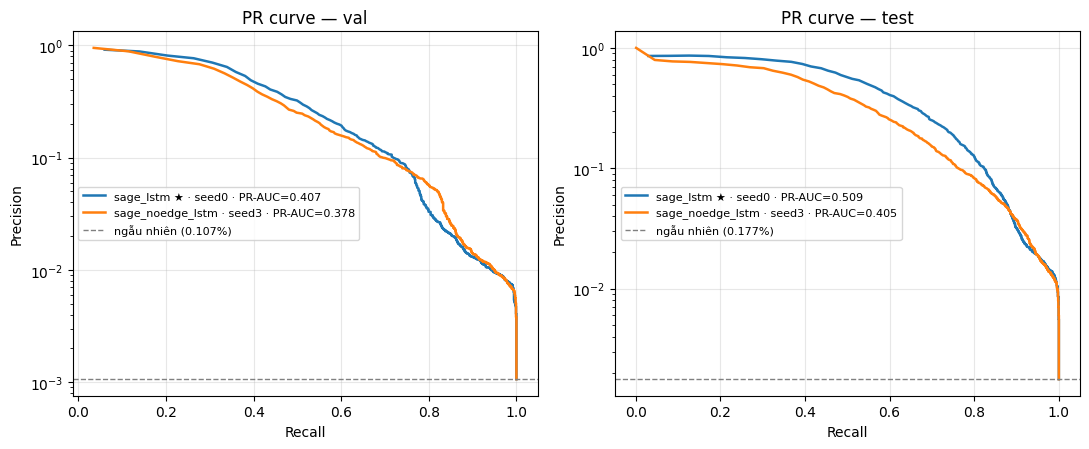

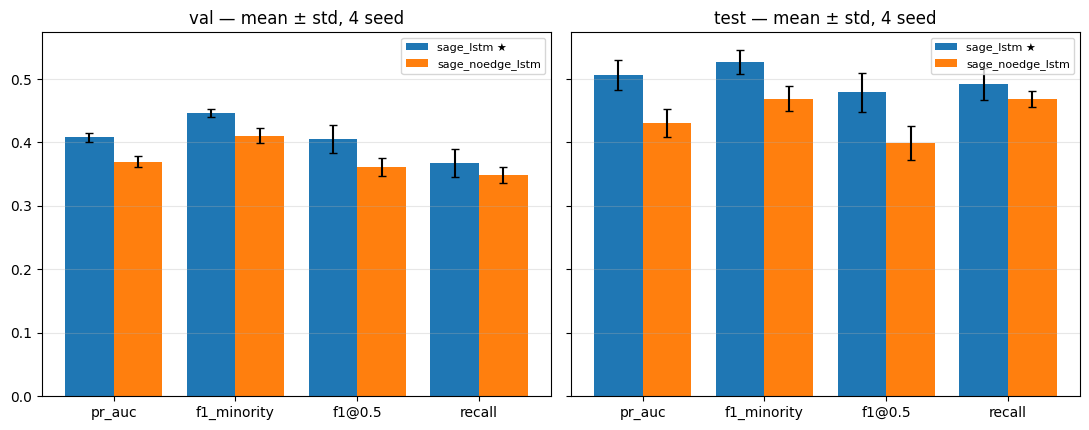

val   | TN=1,014,214 FP=306 FN=682 TP=400 | P=0.5666 R=0.3697 F1=0.4474
test  | TN=1,013,449 FP=635 FN=914 TP=884 | P=0.5820 R=0.4917 F1=0.5330


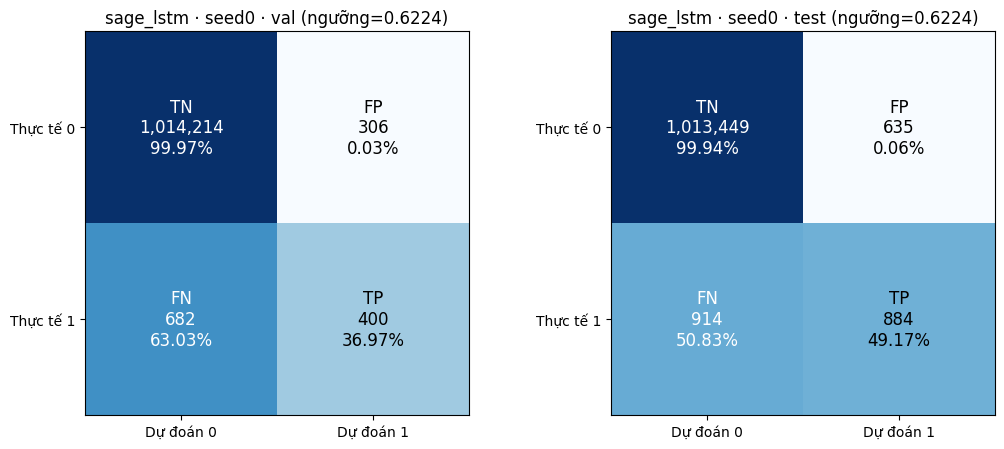

đã lưu: ['confusion_sage_lstm-v3.png', 'variant_bars-v3.png', 'pr_curve-v3.png']


In [28]:
import os, sys, json
sys.path.insert(0, "/kaggle/working")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from paths import TXN_MATRIX, SCORES_DIR, RESULTS_CSV, WORK_DIR

FIG_DIR = os.path.join(WORK_DIR, "figures"); os.makedirs(FIG_DIR, exist_ok=True)
SPLITS, METRICS = ["val", "test"], ["pr_auc", "f1_minority", "f1@0.5", "recall"]

info = json.load(open(os.path.join(WORK_DIR, "winner-v3.json")))
winner, tags = info["winner"], info["variants"]
res = pd.read_csv(RESULTS_CSV)
res = res[res.model.isin(tags)]

# seed đại diện = seed có pr_auc val gần TRUNG VỊ (không lấy seed cao nhất, tránh
# vẽ hình bằng một lần chạy may mắn)
v = res[res.split == "val"]
rep = {t: int(g.loc[(g.pr_auc - g.pr_auc.median()).abs().idxmin(), "seed"])
       for t, g in v.groupby("model")}
print("model thắng:", winner, "| seed đại diện:", rep)
print(res.groupby(["split", "model"])[METRICS].agg(["mean", "std"]).round(4))

y = {s: pd.read_parquet(TXN_MATRIX.format(s),
                        columns=["Is Laundering"])["Is Laundering"].to_numpy() for s in SPLITS}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, sp in zip(axes, SPLITS):
    for t in tags:
        s = np.load(f"{SCORES_DIR}/{t}_seed{rep[t]}_{sp}-v3.npy")
        pr, rc, _ = precision_recall_curve(y[sp], s)
        pr, rc = pr[::100], rc[::100] 
        ap = res[(res.model == t) & (res.split == sp) & (res.seed == rep[t])].pr_auc.iloc[-1]
        ax.plot(rc, pr, lw=1.8,
                label=f"{t}{' ★' if t == winner else ''} · seed{rep[t]} · PR-AUC={ap:.3f}")
    base = y[sp].mean()
    ax.axhline(base, ls="--", c="gray", lw=1, label=f"ngẫu nhiên ({base*100:.3f}%)")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_yscale("log")
    ax.set_title(f"PR curve — {sp}"); ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/pr_curve-v3.png", dpi=150, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
xs, w = np.arange(len(METRICS)), 0.8 / len(tags)
for ax, sp in zip(axes, SPLITS):
    g = res[res.split == sp].groupby("model")[METRICS]
    mu, sd = g.mean(), g.std()
    for i, t in enumerate(tags):
        ax.bar(xs + i * w - 0.4 + w / 2, mu.loc[t], w, yerr=sd.loc[t], capsize=3,
               label=t + (" ★" if t == winner else ""))
    ax.set_xticks(xs); ax.set_xticklabels(METRICS)
    ax.set_title(f"{sp} — mean ± std, {len(info['seeds'])} seed")
    ax.grid(axis="y", alpha=.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/variant_bars-v3.png", dpi=150, bbox_inches="tight"); plt.show()

# ---- Hình 3: confusion matrix của model thắng ----
SEED = rep[winner]
thr = res[(res.model == winner) & (res.seed == SEED) & (res.split == "val")].threshold.iloc[-1]
fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.6))
for ax, sp in zip(axes, SPLITS):
    p = (np.load(f"{SCORES_DIR}/{winner}_seed{SEED}_{sp}-v3.npy") >= thr).astype(int)
    cm = np.array([[int(((y[sp] == a) & (p == b)).sum()) for b in (0, 1)] for a in (0, 1)])
    row = cm / cm.sum(axis=1, keepdims=True)          # chuẩn hoá theo HÀNG = lớp thực tế
    ax.imshow(row, cmap="Blues", vmin=0, vmax=1)
    name = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{name[i][j]}\n{cm[i, j]:,}\n{row[i, j]*100:.2f}%", ha="center",
                    va="center", fontsize=12, color="white" if row[i, j] > .5 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Dự đoán 0", "Dự đoán 1"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Thực tế 0", "Thực tế 1"])
    ax.set_title(f"{winner} · seed{SEED} · {sp} (ngưỡng={thr:.4f})")
    tn, fp, fn, tp = cm.ravel()
    pr_, rc_ = tp / max(tp + fp, 1), tp / max(tp + fn, 1)
    print(f"{sp:5s} | TN={tn:,} FP={fp:,} FN={fn:,} TP={tp:,} | P={pr_:.4f} R={rc_:.4f} "
          f"F1={2*pr_*rc_/max(pr_+rc_, 1e-12):.4f}")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/confusion_{winner}-v3.png", dpi=150, bbox_inches="tight"); plt.show()

print("đã lưu:", os.listdir(FIG_DIR))

In [29]:
# Cell cuối — đóng gói embedding rồi tải về
import os, sys, glob, zipfile
sys.path.insert(0, "/kaggle/working")
from paths import SCORES_DIR, WORK_DIR
from IPython.display import FileLink, display

emb = sorted(glob.glob(f"{SCORES_DIR}/emb-ssl/emb_*.npy"))
assert emb, "không có file emb_*.npy, pretrain_gnn.py chưa chạy xong"

# ZIP_STORED: .npy float32 nén gần như vô ích, gói-không-nén nhanh hơn nhiều lần
out = os.path.join(WORK_DIR, "emb-ssl-v3.zip")
with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:
    for p in emb:
        z.write(p, os.path.basename(p))
print(f"emb-ssl-v3.zip: {len(emb)} file | {os.path.getsize(out)/1e6:,.0f} MB")
display(FileLink("emb-ssl-v3.zip"))

print(f"\n/kaggle/working hiện: "
      f"{sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk('/kaggle/working') for f in fs)/1e9:.2f} GB")

emb-ssl-v3.zip: 24 file | 1,582 MB


/kaggle/working/emb-ssl-v3.zip


/kaggle/working hiện: 8.01 GB


In [30]:
# Cell cuối — gói toàn bộ /kaggle/working/scores
import os, sys, glob, zipfile, datetime
sys.path.insert(0, "/kaggle/working")
from paths import SCORES_DIR, WORK_DIR
from IPython.display import FileLink, display

files = sorted(glob.glob(f"{SCORES_DIR}/*.npy"))
for p in files:                                  # mtime để phân biệt lần chạy cũ/mới
    print(f"{os.path.getsize(p)/1e6:>7,.1f} MB  "
          f"{datetime.datetime.fromtimestamp(os.path.getmtime(p)):%m-%d %H:%M}  "
          f"{os.path.basename(p)}")

out = os.path.join(WORK_DIR, "scores-v3.zip")
with zipfile.ZipFile(out, "w", zipfile.ZIP_STORED) as z:   # không nén: float32 nén vô ích
    for p in files:
        z.write(p, os.path.basename(p))

print(f"\nscores-v3.zip: {len(files)} file | {os.path.getsize(out)/1e6:,.0f} MB")
display(FileLink("scores-v3.zip"))

    4.1 MB  08-17 09:56  sage_lstm_seed0_test-v3.npy
    4.1 MB  08-17 09:56  sage_lstm_seed0_val-v3.npy
    4.1 MB  08-17 10:05  sage_lstm_seed1_test-v3.npy
    4.1 MB  08-17 10:05  sage_lstm_seed1_val-v3.npy
    4.1 MB  08-17 10:15  sage_lstm_seed2_test-v3.npy
    4.1 MB  08-17 10:15  sage_lstm_seed2_val-v3.npy
    4.1 MB  08-17 10:25  sage_lstm_seed3_test-v3.npy
    4.1 MB  08-17 10:25  sage_lstm_seed3_val-v3.npy
    4.1 MB  08-17 10:32  sage_noedge_lstm_seed0_test-v3.npy
    4.1 MB  08-17 10:32  sage_noedge_lstm_seed0_val-v3.npy
    4.1 MB  08-17 10:39  sage_noedge_lstm_seed1_test-v3.npy
    4.1 MB  08-17 10:39  sage_noedge_lstm_seed1_val-v3.npy
    4.1 MB  08-17 10:47  sage_noedge_lstm_seed2_test-v3.npy
    4.1 MB  08-17 10:47  sage_noedge_lstm_seed2_val-v3.npy
    4.1 MB  08-17 10:55  sage_noedge_lstm_seed3_test-v3.npy
    4.1 MB  08-17 10:55  sage_noedge_lstm_seed3_val-v3.npy

scores-v3.zip: 16 file | 65 MB


/kaggle/working/scores-v3.zip